In [1]:
import os
import pathlib

os.chdir(pathlib.Path().resolve())
print("Working directory set to:", os.getcwd())

Working directory set to: D:\github\Transport-Network-Design\Kinshasa\alg\unconstrained\TNDP_main1.0-alpha-sens1.2


<h3>Prerequisite for Collab</h3>

In [2]:
!pip install pyomo

Defaulting to user installation because normal site-packages is not writeable


In [3]:
!pip install highspy

Defaulting to user installation because normal site-packages is not writeable


In [4]:
!pip install pyscipopt

Defaulting to user installation because normal site-packages is not writeable


In [5]:
pip install pyswarms

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [6]:
!pip install shapely

Defaulting to user installation because normal site-packages is not writeable


<h3>Prerequisite for Conda Installation</h3>

In [7]:
#On Mac Terminal: conda create -n optim_env python=3.10
#conda activate optim_env
#conda install -c conda-forge pyomo scip
#conda install -c conda-forge glpk     # Linear / MILP solver
#conda install -c conda-forge highs    # Linear / Quadratic solver
#conda install -c conda-forge ipopt    # Nonlinear solver
#conda install -c conda-forge scip     # MINLP solver
#conda install networkx
#conda install conda-forge::matplotlib

# **I. Network Analysis**

In [8]:
import networkx as nx
import matplotlib.pyplot as plt
import math
import time

# Step 1: Create graph
G2 = nx.Graph()

# Step 2: Define node data with BOTH position and label
# Each entry: node_id: {"pos": (x, y), "label": "..."}
node_data = {
    1:  {"pos": (-4.559058, 15.174809), "label": "Route de Matadi (border Kinshasa)"},
    2:  {"pos": (-4.442848, 15.255100), "label": "Triangle Matadi Kibala"},
    3:  {"pos": (-4.406924, 15.256513), "label": "UPN"},
    4:  {"pos": (-4.349325, 15.238810), "label": "Av. de l'École – Binza"},
    5:  {"pos": (-4.328773, 15.252333), "label": "Mont Ngaliema"},
    6:  {"pos": (-4.310907, 15.288488), "label": "Bd du 30 Juin"},
    7:  {"pos": (-4.299709, 15.319240), "label": "Gare Centrale"},
    8:  {"pos": (-4.398246, 15.276497), "label": "Selembao (Auto Stop)"},
    9:  {"pos": (-4.381511, 15.282728), "label": "Sanatorium"},
    10: {"pos": (-4.337062, 15.295951), "label": "Pierre Mulele"},
    11: {"pos": (-4.395099, 15.307741), "label": "Triangle Campus"},
    12: {"pos": (-4.389760, 15.314763), "label": "Rond Point Ngaba"},
    13: {"pos": (-4.336819, 15.326397), "label": "Av. de l'Université"},
    14: {"pos": (-4.331834, 15.314427), "label": "Bd Triomphal"},
    15: {"pos": (-4.393572, 15.333011), "label": "Lemba"},
    16: {"pos": (-4.375441, 15.344869), "label": "Échangeur 1"},
    17: {"pos": (-4.397829, 15.393514), "label": "Masina"},
    18: {"pos": (-4.405498, 15.423430), "label": "Av. Ndjoku"},
    19: {"pos": (-4.391380, 15.446782), "label": "Aéroport Ndjili"},
    20: {"pos": (-4.384103, 15.470908), "label": "Nsele"},
    21: {"pos": (-4.209434, 15.578420), "label": "RP Nsele"},
    22: {"pos": (-4.202280, 15.613246), "label": "Menkao"},
    23: {"pos": (-4.051282, 15.558907), "label": "Maluku"},
    # 23 intentionally omitted
    24: {"pos": (-4.472585, 15.281341), "label": "Arrêt Gare"},
    25: {"pos": (-4.420154, 15.307442), "label": "UNIKIN"},
    26: {"pos": (-4.461385, 15.288240), "label": "Kimwenza 2"},
    27: {"pos": (-4.484759, 15.219752), "label": "Benseke"},
    28: {"pos": (-4.447334, 15.249644), "label": "Wenze Matadi Kibala"},
    29: {"pos": (-4.329183, 15.337959), "label": "Limete PL"},
    30: {"pos": (-4.353936, 15.335540), "label": "Limete R"},
    
}

# Step 3: Add nodes with attributes
for node, attrs in node_data.items():
    G2.add_node(node, **attrs)  # adds both 'pos' and 'label'

# Step 4: Define edges with names
edges = [
    (1, 27, {"name": "Route de Matadi - Benseke"}),
    (27, 28, {"name": "Benseke - Wenze Matadi Kibala"}),
    (28, 2, {"name": "Wenze (Matadi Kibala) - Triangle (Cité Verte)"}),
    (2, 3, {"name": "Matadi Kibala - UPN"}),
    (3, 4, {"name": "UPN - Binza"}),
    (4, 5, {"name": "Binza - Mont Ngaliema"}),
    (5, 6, {"name": "Boulevard du 30 Juin"}),
    (6, 7, {"name": "24 - Gare Centrale"}),
    (3, 8, {"name": "UPN - Selembao"}),
    (8, 9, {"name": "Sanatorium - Université"}),
    (9, 10, {"name": "Sanatorium - Pierre Mulele"}),
    (10, 6, {"name": "24 Novembre"}),
    (2, 11, {"name": "Triangle (Cité Verte) - Triangle (Campus)"}),
    (11, 12, {"name": "Tr.Campus - RP Ngaba"}),
    (12, 13, {"name": "Av. Université"}),
    (10, 14, {"name": "B. Triomphal"}),
    (13, 14, {"name": "B. Sendwe"}),
    (12, 15, {"name": "RP Ngaba - Lemba"}),
    (15, 16, {"name": "Lemba - Echangeur 1"}),
    (13, 30, {"name": "Sendwe - Limete"}),
    (30, 16, {"name": "Limete. Lumumba 1"}),
    (16, 17, {"name": "Echangeur - Masina"}),
    (17, 18, {"name": "Masina - Av.Ndjoku (B.Lumumba 2)"}),
    (18, 19, {"name": "Av.Ndjoku - Int Aeroport (B.Lumumba 3)"}),#
    (19, 20, {"name": "Aeroport - Nsele"}),#
    (20, 21, {"name": "Nsele - RP. Nsele"}),#
    (21, 22, {"name": "RP.Nsele - Menkao"}),#
    (21, 23, {"name": "RP.Nsele - Maluku"}),#
    (2, 24, {"name": "Triangle Cité Verte - R. Kimwenza"}),#
    (11, 25, {"name": "Triangle Campus - Unikin"}),#
    (12, 25, {"name": "RP Ngaba - Unikin"}),#
    (25, 26, {"name": "Unikin - Kimwenza 2"}),#
    (7, 29, {"name": "Gare Centrale - Poids Lourd"}),#
    (29, 16, {"name": "Poids Lourd - Echangeur"}),#
]
G2.add_edges_from(edges)
G0 = G2.copy()

In [9]:
#(Distance) Calibration -------------------------------------
P1 = node_data[3]['pos']
P2 = node_data[27]['pos']
d = math.sqrt((P1[0]-P2[0])**2 + (P1[1]-P2[1])**2 )
True_d  = 4.2
calibration_score = d/True_d
print(d,calibration_score)
# ----------------------------------------------------------
# Edge lengths (Euclidean from node positions)
# ----------------------------------------------------------
def compute_edge_lengths(G):
    #pos = nx.get_node_attributes(G, 'pos')
    lengths = {}
    for (u, v) in G.edges(): 
        x1, y1 = node_data[u]['pos']
        x2, y2 = node_data[v]['pos']
        lengths[(u, v)] = ((x1 - x2) ** 2 + (y1 - y2) ** 2) ** 0.5
    return lengths

0.08607937236063044 0.02049508865729296


<h3>Problem Configuration</h3>

In [10]:
from joblib import load

demand_dict = load("../../../data/od_demand_orig2.joblib")
print("Loaded", len(demand_dict), "OD pairs.")


Loaded 114 OD pairs.


In [11]:
#----- Complete Graph
Gc = nx.complete_graph(G0.nodes()) #complete graph
Gs = Gc.copy()
Gs.remove_edges_from(G0.edges())
complete_edge_list = Gs.edges()
#---- System Configuration ----------------------
lengths = compute_edge_lengths(Gc)
cost_weights = {(i,j): lengths[i,j] for (i,j) in Gc.edges()}
CALIB = calibration_score
#------------------------------------------------------ JSON --------------------
import json
with open("config.json", "r") as f:
    config = json.load(f)

Budget = config["Budget"]
v_avg = config["v_avg"]
penalty_factor = config["penalty_factor"]
optim_max_iter = config["optim_max_iter"]
optim_pop_size = config["optim_pop_size"]
n_runs = config["n_runs"]
folder = config["folder"]
C = config["C"]
alpha = config["alpha"]
#multiply demand
for key in demand_dict:
    demand_dict[key] = config["demand_scale"]*demand_dict[key]
#-------- Demand Data ---------------------------
OD_pairs = demand_dict.keys() #[(1,27),(16,18),(5,7),(10,13)] #Origin Destination Pairs
demand_paths = demand_dict# {(1,27):25, (16,18):15, (5,7):15, (10,13):18}
#----------------------------------------------------------------------------------
travel_t0 = {(i,j):(cost_weights[i,j]/calibration_score)/v_avg for (i,j) in Gc.edges()}
travel_alpha = {(i,j):alpha for (i,j) in Gc.edges()}
#Optimisation settings
optim_stall_iter = optim_max_iter*optim_pop_size
#SA
sa_T0 = 1e0
sa_Tmin = 1e-3
sa_alpha = 0.99

<h3>Analysis</h3>

In [12]:
import math
import networkx as nx
import matplotlib.pyplot as plt

def draw_rotated_graph(
    G,
    degrees=-90,
    figsize=(10, 8),
    invert_x=True,
    edge_flows=None,
    scale=1/200,
    show_labels=True,
    node_size=120,
    spread=2.0,
    label_pos=0.55,
    node_font_size=6,
    edge_font_size=6
):

    def rotate_pos(pos_dict, degrees):
        theta = math.radians(degrees)
        cos_t, sin_t = math.cos(theta), math.sin(theta)
        return {
            n: (x * cos_t + y * sin_t, -x * sin_t + y * cos_t)
            for n, (x, y) in pos_dict.items()
        }

    # Get positions
    pos = nx.get_node_attributes(G, 'pos')
    if not pos:
        pos = nx.spring_layout(G, seed=42, k=1.0)

    pos_rotated = rotate_pos(pos, degrees)
    pos_scaled = {n: (x*spread, y*spread) for n, (x,y) in pos_rotated.items()}

    # Edge widths
    edge_widths = []
    for (u,v) in G.edges():
        flow = 0.0
        if edge_flows:
            flow = edge_flows.get((u, v), edge_flows.get((v, u), 0.0))
        edge_widths.append(max(0.5, flow * scale))

    # Edge color normalization
    edge_values = []
    if edge_flows:
        flow_vals = [
            edge_flows.get((u,v), edge_flows.get((v,u), 0.0))
            for (u,v) in G.edges()
        ]
        f_min, f_max = min(flow_vals), max(flow_vals)

        for (u,v) in G.edges():
            f = edge_flows.get((u,v), edge_flows.get((v,u), 0.0))
            norm_f = (f - f_min) / (f_max - f_min) if f_max > f_min else 0.0
            edge_values.append(norm_f)
    else:
        edge_values = "grey"

    # Plot
    plt.figure(figsize=figsize)
    nx.draw_networkx_nodes(G, pos_scaled, node_size=node_size, node_color="lightblue")
    nx.draw_networkx_labels(G, pos_scaled, font_size=node_font_size, font_weight="bold")

    nx.draw_networkx_edges(
        G,
        pos_scaled,
        width=edge_widths,
        edge_color=edge_values,
        edge_cmap=plt.cm.RdYlGn_r,  # green=low, red=high
        arrows=G.is_directed()
    )

    if edge_flows and show_labels:
        edge_labels = {
            (u,v): f"{edge_flows.get((u,v), edge_flows.get((v,u), 0.0)):.2f}"
            for (u,v) in G.edges()
        }
        nx.draw_networkx_edge_labels(
            G,
            pos_scaled,
            edge_labels=edge_labels,
            font_size=edge_font_size,
            label_pos=label_pos,
            font_color="brown"
        )

    if invert_x:
        plt.gca().invert_xaxis()

    plt.axis("off")
    plt.show()


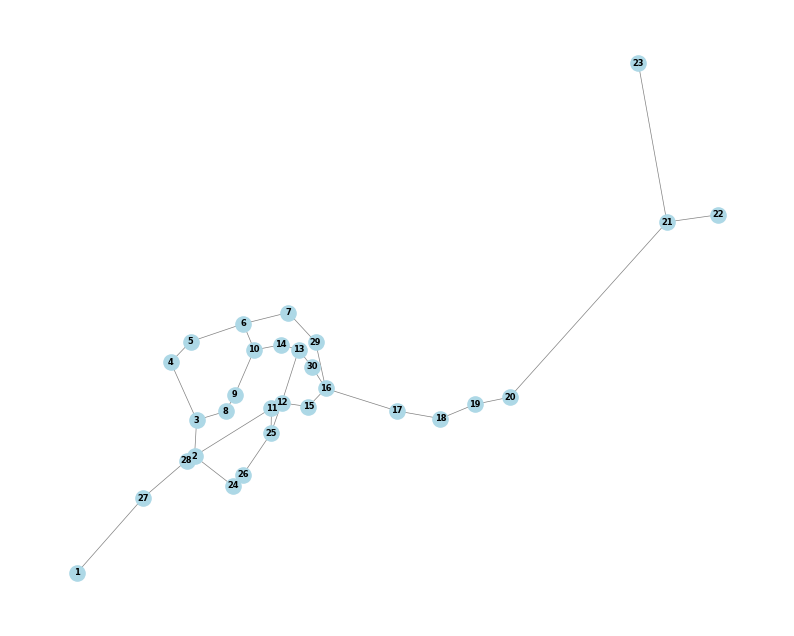

In [13]:
draw_rotated_graph(G2)

In [14]:
#Optimisation Preparation
import networkx as nx
Gs = Gc.copy()
Gs.remove_edges_from(G0.edges())
print('[0] Initial Network:',G0, '\n[1] Complete Network:', Gc,'\n[2] Solution Network:',Gs)
#candidate solution
Gi = G0
def get_simple_paths(Gi, r, s):
  return list(nx.all_simple_paths(Gi,source=r,target=s))

[0] Initial Network: Graph with 30 nodes and 34 edges 
[1] Complete Network: Graph with 30 nodes and 435 edges 
[2] Solution Network: Graph with 30 nodes and 401 edges


In [15]:
from shapely.geometry import LineString
from shapely.strtree import STRtree
import itertools

def precompute_intersections(node_data):
    """
    Compute all intersecting edge pairs in a complete geometric graph.

    Parameters
    ----------
    node_data : dict
        {node_id: {"pos": (x, y)}}

    Returns
    -------
    list[tuple]
        [((u1, v1), (u2, v2)), ...] where each pair of edges intersects.
    """

    # === 1. Build edge list and geometries ===
    nodes = list(node_data.keys())
    edges = [(u, v) for u, v in itertools.combinations(nodes, 2)]
    geoms = [LineString([node_data[u]["pos"], node_data[v]["pos"]]) for u, v in edges]

    # === 2. Build spatial index ===
    tree = STRtree(geoms)

    # === 3. Map geometry id back to its index ===
    # These are actual geometry objects used in the tree.
    geom_to_index = {g: i for i, g in enumerate(geoms)}

    # === 4. Compute intersections ===
    intersection_pairs = set()

    for i, geom1 in enumerate(geoms):
        edge1 = edges[i]
        for geom2 in tree.query(geom1):
            # Some STRtree versions return proxy types; skip if not valid geometry
            if not isinstance(geom2, LineString):
                continue

            j = geom_to_index.get(geom2)
            if j is None or j == i:
                continue
            edge2 = edges[j]

            # Skip shared endpoints
            if set(edge1) & set(edge2):
                continue

            # Use .crosses() which ensures proper line intersection (not touching)
            if geom1.crosses(geom2):
                intersection_pairs.add(tuple(sorted([edge1, edge2])))

    return list(intersection_pairs)


In [16]:
precomputed_pairs = precompute_intersections(node_data)
precomputed_pairs

[]

In [17]:
def count_intersections_subnetwork(G, precomputed_pairs):
    """
    Count how many of the precomputed intersection pairs exist in G.
    """
    edges_in_G = set(tuple(sorted(e)) for e in G.edges())
    count = sum(1 for (e1, e2) in precomputed_pairs
                if e1 in edges_in_G and e2 in edges_in_G)
    return count


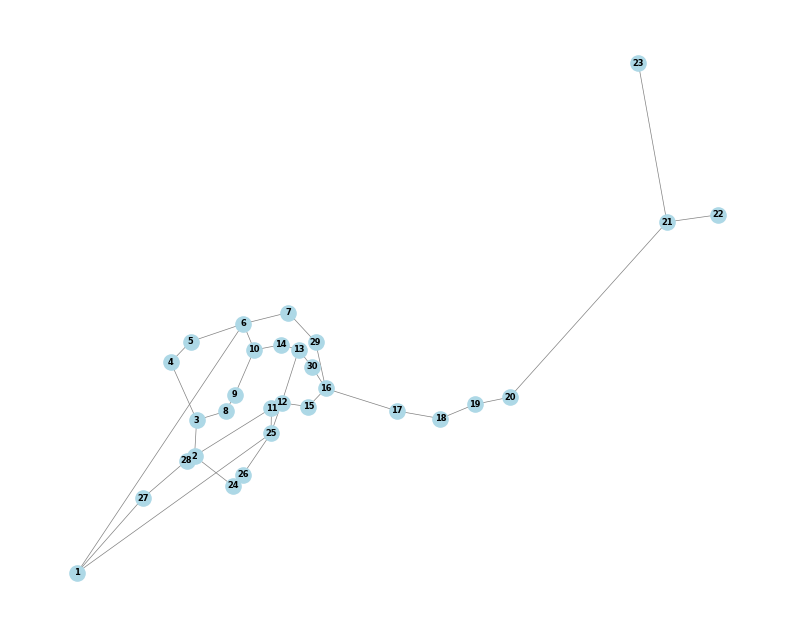

In [18]:
Gi_ = G0.copy()
Gi_.add_edges_from([(1,25),(1,6)])
draw_rotated_graph(Gi_)

In [19]:
#num_intersections = count_intersections(Gi_, node_data)
#print("Number of geometric intersections:", num_intersections)

# **I. Greedy Algorithm**

A transportation network design problem (TNDP) is formulated as bilevel optimisation problem.

\begin{align}
  \textbf{ULP}: \underset{y}{Minimise} \text{ }\quad  & \underset{}{T(y) = \sum_{(i,j)\in \Gamma \cup E}x^*_{i,j}t_{ij}(x^*_{i,j})}\\
   s.t\quad  & \sum_{}^{}c_{i,j}y_{i,j } \leq  B\\
   \quad & y_{i,j}\in\{0,1\}\\
   \quad & x^*_{i,j} = \text{arg min }F(x,f,y)\\
   \textbf{LLP}: \underset{x, f}{Minimise} \text{ }\quad & \underset{}{F(x,f,y) = \sum_{(i,j)\in \Gamma\cup E} \int_{0}^{x_{i,j}}t_{i,j}(w)dw}\\
   s.t\quad & x_{i,j}=\sum_{P_{r,s}\in E\cup \Gamma}\sum_{k\in P_{r,s}}f_k\delta_k^{i,j}\\
   \quad & \sum_{k\in P_{r,s}}f_k=d_{r,s}\\
   \quad & f_k\geq 0\\
   \quad & x_{i,j}\geq 0\\
   \quad & \delta_k^{i,j}\in \{0,1\}
\end{align}
where $y_{i,j}$ is a decision variable to add or remove an edge $(i,j)$, $x_{i,j}$ is the overall flow rate of the edge $(i,j)$, $f_k$ is the flow of a path $k$ in a given origin destination pair $(r,s)$ and $\delta_k^{i,j}$ a network structure variable that excludes a flow $f_k$ if it does not go through $x_{i,j}$.

The travel time function is typically given \cite{babazadeh2011application,koh2007solving,zhang2009bilevel} as
\begin{equation}
t(x) = t_{ij}(x_{ij}) = \alpha_{ij}+\beta_{ij}x_{ij}^4   
\end{equation}


<h3>Greedy Algorithm</h3>
In the problem of network augmentation, a greedy algorithm proposed can be used to iteratively identify a good candidate subset that will minimise $T(y)$ using a step-by-step greedy addition of local best links \cite{medya2018group}. The advantage of greedy algorithms is in providing stable, efficient and ``good'' solutions (see algorithm \ref{alg:greedy}).

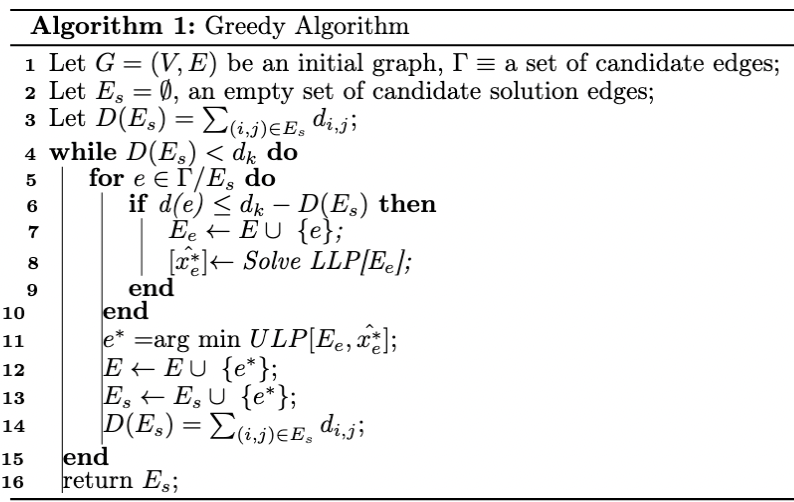

At each iteration, a sample candidate edge is selected from $\Gamma/E_s$ and added to a novel network $G_e$ with more edge additions. The edge that yields the best cost function minimisation is added to the candidate solution pool $E_s$, and as such, the network is updated, the candidate subset and termination constraint are updated. This process continues until a termination criterion is reached.

<h3>Lower Level Problem Solver</h3>

In [20]:
import pyomo.environ as pyo
from pyomo.opt import SolverStatus, TerminationCondition
import networkx as nx

# ---------------------------
# Helpers
# ---------------------------
def var2edge(edge_list, y_var):
    return [edge for edge, y_i in zip(edge_list, y_var) if y_i == 1]

def edge2var(edge_list, edges_):
    return [1 if (i, j) in edges_ or (j, i) in edges_ else 0 for (i, j) in edge_list]

def travel_time_discrete(t0, alpha, x_ij, C=C):
    return t0 * (1 + alpha * (x_ij / C) ** 4)

# ---------------------------
# Helpers (undirected-safe)
# ---------------------------
def travel_time_integral(t0, alpha, x_ij, C=C):
    # ∫ t0(1+α(x/C)^4) dx = t0(x + α*x^5/(5*C^4))
    return t0 * (x_ij + 0.2 * alpha * (x_ij**5) / (C**4))


def get_param_undirected(param_dict, i, j):
    if (i, j) in param_dict:
        return param_dict[(i, j)]
    if (j, i) in param_dict:
        return param_dict[(j, i)]
    raise KeyError(f"Missing parameter for edge {(i, j)} / {(j, i)}")


def configure_ipopt(solver, display=False):
    # Iterations / tolerances
    solver.options["max_iter"] = 5000
    solver.options["tol"] = 1e-7
    solver.options["acceptable_tol"] = 1e-6
    solver.options["acceptable_iter"] = 10

    # Robustness
    solver.options["mu_strategy"] = "adaptive"
    solver.options["nlp_scaling_method"] = "gradient-based"

    # Linear solver (depends on your IPOPT build)
    solver.options["linear_solver"] = "mumps"

    # Bound handling
    solver.options["bound_push"] = 1e-8
    solver.options["bound_frac"] = 1e-8

    # Output
    solver.options["print_level"] = 5 if display else 0
    return solver


# ---------------------------
# Lower Level Problem Solver (LLP) with DEBUG MARKERS
# ---------------------------
def LLP_problem_solve(
    G_0,
    design_edges,
    OD_pairs,
    demand_paths,
    travel_t0,
    travel_alpha,
    display=False,
    solver_="ipopt",
    k_paths=5,
    weight_attr="length",
    flow_upper_bound=None,   # if None, uses total OD demand
    keepfiles=False,
    logfile=None,
    # ---- debug controls ----
    debug_tag: str = "",
    debug_stop: bool = False,
    suspicious_Lopt_tol: float = 1e-12
):
    """
    Solves the LLP with IPOPT robustly, intended to be called many times in a greedy/TS loop.

    Debug markers:
      <<<LLP_DEBUG>>> NO_PATHS
      <<<LLP_DEBUG>>> ZERO_TOTAL_DEMAND
      <<<LLP_DEBUG>>> SOLVER_FAIL
      <<<LLP_DEBUG>>> SUSPICIOUS_L_OPT
    """

    # Build design network
    Gi = G_0.copy()
    Gi.add_edges_from(design_edges)

    # Build up to k shortest simple paths for each OD
    def get_flow_paths(G, r, s, k=k_paths, weight=weight_attr):
        gen = nx.shortest_simple_paths(G, source=r, target=s, weight=weight)
        paths_ = []
        for idx, path in enumerate(gen):
            if idx >= k:
                break
            paths_.append(list(zip(path[:-1], path[1:])))
        return paths_

    flow_paths = {(r, s): get_flow_paths(Gi, r, s) for (r, s) in OD_pairs}

    # --- DEBUG: disconnected OD pairs (no feasible path) ---
    disconnected = [(r, s) for (r, s), paths in flow_paths.items() if len(paths) == 0]
    if disconnected:
        msg = (
            f"<<<LLP_DEBUG>>> NO_PATHS | tag={debug_tag} | "
            f"|E_design|={len(design_edges)} | disconnected_ODs={len(disconnected)} | "
            f"examples={disconnected[:5]}"
        )
        print(msg)
        if debug_stop:
            raise RuntimeError(msg)
        return float("inf"), {}, {}

    # Create path-flow indices and dictionary mapping variable -> list of edges
    flow_dics = {}
    flow_vars_inds = []
    for (r, s), paths in flow_paths.items():
        for ii, path_edges in enumerate(paths, start=1):
            name = f"{(r, s)}_{ii}"
            flow_dics[name] = path_edges
            flow_vars_inds.append(name)

    # Compute stable upper bound for flows (prevents numerical explosion)
    total_demand = float(sum(float(demand_paths[(r, s)]) for (r, s) in OD_pairs))

    # --- DEBUG: total demand is zero (often a key mismatch bug) ---
    if total_demand <= 0:
        msg = (
            f"<<<LLP_DEBUG>>> ZERO_TOTAL_DEMAND | tag={debug_tag} | "
            f"total_demand={total_demand} | |OD_pairs|={len(OD_pairs)} | "
            f"examples_OD={OD_pairs[:5]}"
        )
        print(msg)
        if debug_stop:
            raise RuntimeError(msg)
        return float("inf"), {}, {}

    ub = float(flow_upper_bound) if flow_upper_bound is not None else total_demand
    if ub <= 0:
        # Extremely defensive: should not happen if total_demand>0
        ub = total_demand

    # Pyomo model
    m = pyo.ConcreteModel()

    # Decision variables with bounds
    m.x_ij = pyo.Var(Gi.edges(), within=pyo.NonNegativeReals, bounds=(0.0, ub))
    m.f_k = pyo.Var(flow_vars_inds, within=pyo.NonNegativeReals, bounds=(0.0, ub))

    # Demand satisfaction per OD: sum of path flows = demand
    def flow_demand_rule(model, r, s):
        return sum(
            model.f_k[f"{(r, s)}_{ii+1}"] for ii in range(len(flow_paths[(r, s)]))
        ) == float(demand_paths[(r, s)])

    m.constraint_flow = pyo.Constraint(OD_pairs, rule=flow_demand_rule)

    # Link-path consistency: x_ij equals sum of all path flows that use (i,j)
    def flow_xij_rule(model, i, j):
        expr = 0.0
        for key, path in flow_dics.items():
            if (i, j) in path or (j, i) in path:
                expr += model.f_k[key]
        return expr == model.x_ij[i, j]

    m.constraint_flow_xij = pyo.Constraint(Gi.edges(), rule=flow_xij_rule)

    # Objective: sum of integrals over edges
    m.obj = pyo.Objective(
        expr=sum(
            travel_time_integral(
                get_param_undirected(travel_t0, i, j),
                get_param_undirected(travel_alpha, i, j),
                m.x_ij[i, j],
            )
            for (i, j) in m.x_ij
        ),
        sense=pyo.minimize,
    )

    # Initialisation (helps IPOPT stability)
    for (i, j) in m.x_ij:
        m.x_ij[i, j].value = 0.0

    # Put each OD demand on the first path (feasible start in path space)
    for (r, s) in OD_pairs:
        dem = float(demand_paths[(r, s)])
        for ii in range(len(flow_paths[(r, s)])):
            name = f"{(r, s)}_{ii+1}"
            m.f_k[name].value = dem if ii == 0 else 0.0

    # Solve with robust failure handling
    solver = pyo.SolverFactory(solver_)
    if solver is None or (hasattr(solver, "available") and not solver.available()):
        raise RuntimeError(f"Solver '{solver_}' is not available in your environment.")

    if solver_ == "ipopt":
        solver = configure_ipopt(solver, display=display)

    solve_kw = dict(tee=display, load_solutions=False)
    if keepfiles:
        solve_kw["keepfiles"] = True
    if logfile is not None:
        solve_kw["logfile"] = logfile

    results = solver.solve(m, **solve_kw)

    ok_terms = {
        TerminationCondition.optimal,
        TerminationCondition.locallyOptimal,
        TerminationCondition.feasible,
    }

    # --- DEBUG: solver status/termination failure ---
    if (results.solver.status != SolverStatus.ok) or (results.solver.termination_condition not in ok_terms):
        msg = (
            f"<<<LLP_DEBUG>>> SOLVER_FAIL | tag={debug_tag} | "
            f"|E_design|={len(design_edges)} | total_demand={total_demand:.6g} | "
            f"status={results.solver.status} | term={results.solver.termination_condition}"
        )
        print(msg)
        if display:
            print("  message:", getattr(results.solver, "message", ""))
        if debug_stop:
            raise RuntimeError(msg)
        return float("inf"), {}, {}

    # Load and extract solution
    m.solutions.load_from(results)

    x_flows = {(i, j): float(pyo.value(m.x_ij[i, j])) for (i, j) in m.x_ij}
    f_flows = {k: float(pyo.value(m.f_k[k])) for k in m.f_k}
    L_opt = float(pyo.value(m.obj))

    # --- DEBUG: suspiciously tiny objective (common when demand accidentally near 0) ---
    if L_opt < suspicious_Lopt_tol:
        msg = (
            f"<<<LLP_DEBUG>>> SUSPICIOUS_L_OPT | tag={debug_tag} | "
            f"L_opt={L_opt:.3e} | total_demand={total_demand:.6g} | "
            f"|E_design|={len(design_edges)} | |x|={len(m.x_ij)}"
        )
        print(msg)
        if debug_stop:
            raise RuntimeError(msg)

    if display:
        print(f"Number of x-variables: {len(m.x_ij)}")
        for (i, j), val in list(x_flows.items())[:20]:
            print(f"x[{i},{j}] = {val}")
        if len(x_flows) > 20:
            print("... (truncated)")

        print(f"Number of f-variables: {len(m.f_k)}")
        for k, val in list(f_flows.items())[:20]:
            print(f"f[{k}] = {val}")
        if len(f_flows) > 20:
            print("... (truncated)")

        print("Objective (L_opt):", L_opt)

    return L_opt, x_flows, f_flows

<h3>Lower Level Problem - Case Study</h3>

In [21]:
E_e = [(26,4)] #Design edges
L_opt, x_flows, f_flows = LLP_problem_solve(G0, 
                                            design_edges=E_e, 
                                            OD_pairs=OD_pairs, 
                                            demand_paths=demand_paths,
                                            travel_t0=travel_t0,
                                            travel_alpha=travel_alpha,
                                            display=False
                                           )


In [22]:
print("\n--- Results ---")
print("Objective =", L_opt)


--- Results ---
Objective = 1626.0458945890273


In [23]:
print('Number of x-variables: ',len(x_flows),'\n')
for (i,j) in x_flows:
    print(f"x[{i},{j}] =",x_flows[i,j] )

Number of x-variables:  35 

x[13,30] = 1460.6592514012375
x[3,4] = 166.13200632644018
x[16,29] = 1802.6879998758093
x[16,17] = 2178.903999999999
x[7,29] = 1556.6880001663062
x[12,13] = 469.27896333404453
x[21,22] = 541.692
x[8,9] = 645.5042832038545
x[12,25] = 5.004930497497607e-07
x[17,18] = 1158.0039999999995
x[2,11] = 1654.5957101567085
x[27,28] = 1670.3399999999997
x[25,26] = -9.026265139337369e-09
x[13,14] = 1282.6442893850333
x[1,27] = 1670.3399999999997
x[18,19] = 1158.0039999999995
x[4,5] = 124.47600627979361
x[5,6] = 897.2440060223115
x[12,15] = 1153.8287475014906
x[4,26] = -9.026265139337369e-09
x[9,10] = 756.6962831445545
x[10,14] = 1523.8882891036208
x[19,20] = 541.692
x[6,7] = 1325.1200001642621
x[11,25] = 6.073330853288308e-07
x[15,16] = 1612.3727474905133
x[2,28] = 1670.3399999999997
x[6,10] = 1724.7879933341123
x[16,30] = 1510.364748694602
x[21,23] = -2.9128072522606054e-41
x[20,21] = 541.692
x[3,8] = 637.3042832667062
x[2,3] = 803.4362895611185
x[11,12] = 1654.5957096

In [24]:
print('Number of f-variables: ',len(f_flows),'\n')
for k in f_flows:
    print(f"f[{k}] =", f_flows[k])


Number of f-variables:  530 

f[(1, 2)_1] = 41.738
f[(1, 4)_1] = 20.82800000048587
f[(1, 4)_2] = 1.7666374337192385e-09
f[(1, 4)_3] = 3.5356018768641324e-10
f[(1, 4)_4] = 6.723269389437453e-10
f[(1, 4)_5] = -3.2783923436582554e-09
f[(1, 5)_1] = 62.23799999202428
f[(1, 5)_2] = 1.766637026902368e-09
f[(1, 5)_3] = 7.059757041437984e-09
f[(1, 5)_4] = 3.5355992311570215e-10
f[(1, 5)_5] = -1.2042395256328703e-09
f[(1, 7)_1] = 1.559462969318876e-06
f[(1, 7)_2] = 9.623942251626635e-09
f[(1, 7)_3] = 83.0659984210674
f[(1, 7)_4] = 1.6881948783455653e-09
f[(1, 7)_5] = 8.157502304287118e-09
f[(1, 9)_1] = 27.798000010951547
f[(1, 9)_2] = -1.817969145054236e-09
f[(1, 9)_3] = -1.846816166848109e-09
f[(1, 9)_4] = -3.9290266078171175e-09
f[(1, 9)_5] = -3.3577378147513784e-09
f[(1, 10)_1] = 83.0659999844834
f[(1, 10)_2] = 8.15750230428711e-09
f[(1, 10)_3] = 8.016044081854119e-09
f[(1, 10)_4] = 1.9890947904597216e-09
f[(1, 10)_5] = -2.6460459043114687e-09
f[(1, 12)_1] = 103.23799996808323
f[(1, 12)_2] = 

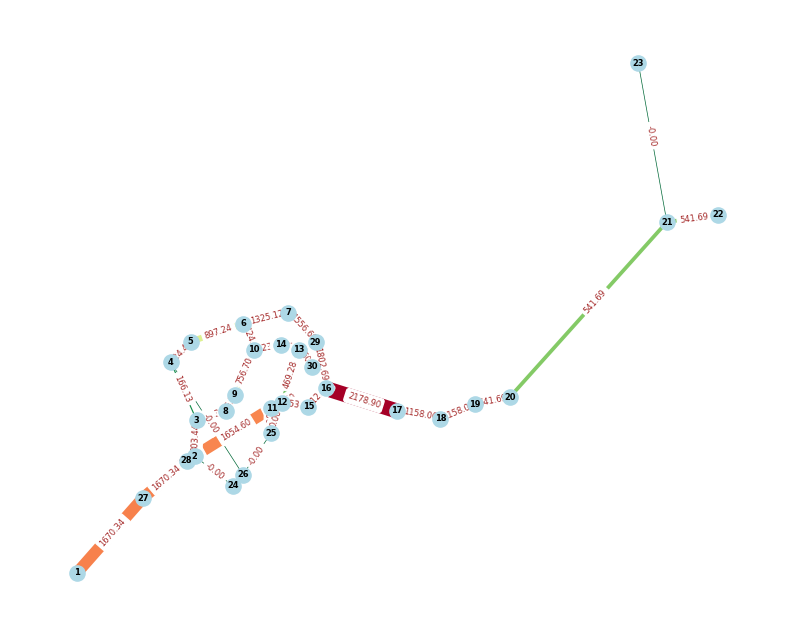

In [25]:
Gi = G0.copy()
Gi.add_edges_from(E_e)
draw_rotated_graph(Gi,edge_flows=x_flows)

<h3>Upper Level Problem</h3>

In [26]:
import math
from typing import Any, Dict, List, Tuple

def _canon_edge(e: Tuple[Any, Any]) -> Tuple[Any, Any]:
    a, b = e
    return (a, b) if a <= b else (b, a)

def _get_param_undirected(param_dict: Dict[Tuple[Any, Any], float], i: Any, j: Any) -> float:
    if (i, j) in param_dict:
        return float(param_dict[(i, j)])
    if (j, i) in param_dict:
        return float(param_dict[(j, i)])
    raise KeyError(f"Missing parameter for edge {(i, j)} / {(j, i)}")

def _safe_cost_undirected(cost_weights: Dict[Tuple[Any, Any], float], e: Tuple[Any, Any]) -> float:
    i, j = e
    return _get_param_undirected(cost_weights, i, j)

def Upper_Level_Problem_obj_func(
    G0,
    y_vars=None,
    OD_pairs=None,
    demand_paths=None,
    travel_t0=None,
    travel_alpha=None,
    cost_weights=None,
    budget: float = 100.0,
    penalty_factor: float = 1e9,
    calib: float = 1.0,
    complete_edge_vars=None,
    display: bool = False,
    # ---- robustness knobs ----
    robust_fail_value: float = float("inf"),
    debug_tag: str = "",
    debug_stop: bool = False,
    suspicious_obj_tol: float = 1e-12,
):
    """
    Robust ULP objective wrapper.

    Key fixes:
    1) If LLP fails (returns inf or empty flows), ULP returns +inf (NOT 0).
    2) All edge lookups (t0/alpha/cost) are undirected-safe.
    3) Guards against NaN/inf objective values.
    4) Optional debug markers for fast diagnosis.
    """

    # ---------------------------
    # Basic input sanity
    # ---------------------------
    if y_vars is None or complete_edge_vars is None:
        raise ValueError("y_vars and complete_edge_vars must be provided.")
    if len(y_vars) != len(complete_edge_vars):
        raise ValueError(f"Length mismatch: len(y_vars)={len(y_vars)} vs len(complete_edge_vars)={len(complete_edge_vars)}")

    if cost_weights is None or travel_t0 is None or travel_alpha is None:
        raise ValueError("cost_weights, travel_t0, and travel_alpha must be provided.")

    # ---------------------------
    # Canonicalise edges for consistent membership
    # ---------------------------
    complete_edge_vars_c = [_canon_edge(e) for e in complete_edge_vars]
    y_vars_int = [1 if int(round(v)) == 1 else 0 for v in y_vars]  # tolerate floats/bools

    # Selected design edges
    E_e = [e for e, y_i in zip(complete_edge_vars_c, y_vars_int) if y_i == 1]

    # Canonicalise cost dict (undirected safe already via lookup, but this also normalises keys)
    cost_weights_c = {_canon_edge(e): float(c) for e, c in cost_weights.items()}

    # ---------------------------
    # Solve LLP (robust LLP recommended)
    # ---------------------------
    L_opt, x_flows, f_flows = LLP_problem_solve(
        G0,
        design_edges=E_e,
        OD_pairs=OD_pairs,
        demand_paths=demand_paths,
        travel_t0=travel_t0,
        travel_alpha=travel_alpha,
        display=display,
        # If you are using the DEBUG LLP version, these args will be accepted:
        debug_tag=debug_tag,
        debug_stop=debug_stop,
    )

    # ---------------------------
    # Robust failure handling:
    # If LLP fails, NEVER allow 0 objective via empty x_flows
    # ---------------------------
    if (x_flows is None) or (not isinstance(x_flows, dict)) or (len(x_flows) == 0):
        msg = f"<<<ULP_DEBUG>>> EMPTY_XFLOWS => LLP failed/invalid | tag={debug_tag} | |E_design|={len(E_e)}"
        if display:
            print(msg)
        if debug_stop:
            raise RuntimeError(msg)
        return robust_fail_value, {}, robust_fail_value

    if (L_opt is None) or (not math.isfinite(float(L_opt))):
        msg = f"<<<ULP_DEBUG>>> NONFINITE_L_OPT | tag={debug_tag} | L_opt={L_opt} | |E_design|={len(E_e)}"
        if display:
            print(msg)
        if debug_stop:
            raise RuntimeError(msg)
        return robust_fail_value, {}, robust_fail_value

    # ---------------------------
    # Compute ULP objective (discrete link cost)
    # Use undirected-safe parameter lookups
    # ---------------------------
    try:
        obj_value = 0.0
        for (i, j), xij in x_flows.items():
            t0 = _get_param_undirected(travel_t0, i, j)
            a = _get_param_undirected(travel_alpha, i, j)
            obj_value += float(xij) * float(travel_time_discrete(t0, a, float(xij)))
    except KeyError as ke:
        msg = f"<<<ULP_DEBUG>>> PARAM_MISSING | tag={debug_tag} | err={ke}"
        if display:
            print(msg)
        if debug_stop:
            raise
        return robust_fail_value, {}, robust_fail_value

    if not math.isfinite(obj_value):
        msg = f"<<<ULP_DEBUG>>> NONFINITE_OBJ | tag={debug_tag} | obj={obj_value}"
        if display:
            print(msg)
        if debug_stop:
            raise RuntimeError(msg)
        return robust_fail_value, {}, robust_fail_value

    # ---------------------------
    # Budget penalty (undirected-safe cost lookup)
    # ---------------------------
    try:
        total_cost = sum(_safe_cost_undirected(cost_weights_c, e) for e in E_e)
    except KeyError as ke:
        msg = f"<<<ULP_DEBUG>>> COST_MISSING | tag={debug_tag} | err={ke}"
        if display:
            print(msg)
        if debug_stop:
            raise
        return robust_fail_value, {}, robust_fail_value

    penalty = max(0.0, float(total_cost) - float(budget) * float(calib))
    pure_cost = float(obj_value)
    obj_value = float(obj_value) + float(penalty_factor) * float(penalty)

    # ---------------------------
    # Suspicious near-zero objective marker (helps catch silent data bugs)
    # ---------------------------
    if pure_cost < suspicious_obj_tol:
        msg = (
            f"<<<ULP_DEBUG>>> SUSPICIOUS_PURE_COST | tag={debug_tag} | "
            f"pure_cost={pure_cost:.3e} | L_opt={float(L_opt):.3e} | "
            f"|E_design|={len(E_e)} | total_cost={total_cost:.6g}"
        )
        if display:
            print(msg)
        if debug_stop:
            raise RuntimeError(msg)

    return obj_value, x_flows, pure_cost


# ---------------------------
# Example test (same as yours)
# ---------------------------
y_vars = edge2var(complete_edge_list, [])
obj_value, x_flows, pure_cost = Upper_Level_Problem_obj_func(
    G0,
    y_vars=y_vars,
    OD_pairs=OD_pairs,
    demand_paths=demand_paths,
    travel_t0=travel_t0,
    travel_alpha=travel_alpha,
    budget=Budget,
    cost_weights=cost_weights,
    complete_edge_vars=complete_edge_list,
    display=False,
    debug_tag="ULP_TEST_EMPTY",
)
print("\n\nUpper problem value:", obj_value)



Upper problem value: 2000.9422189092404


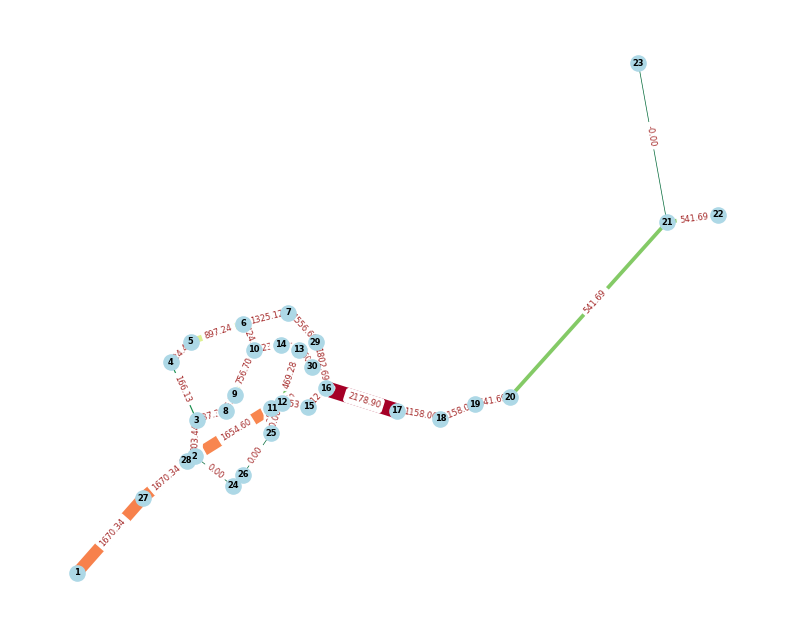

In [27]:
E_e = [edge for edge,y_i in zip(complete_edge_list,y_vars) if y_i== 1]
Gi = G0.copy()
Gi.add_edges_from(E_e)
draw_rotated_graph(Gi,edge_flows=x_flows)

In [28]:
def evaluate_upper_level(selected_edges, display=False):
    """
    Evaluate the Upper-Level Problem (ULP) given a list of selected edges only.
    
    Parameters
    ----------
    selected_edges : list of tuples
        Edges to add to the base network, e.g. [(26,4), (26,23)].
    display : bool, optional
        If True, prints progress and diagnostic details.

    Returns
    -------
    obj_value : float
        Objective value of the upper-level problem.
    x_flows : dict
        Flow solution from the lower-level problem.
    """

    # === Access or import the encapsulated parameters ===
    global G0, complete_edge_list, OD_pairs, demand_paths
    global travel_t0, travel_alpha, cost_weights, Budget, CALIB

    # --- Convert edge list to binary decision vector ---
    y_vars = [1 if e in selected_edges else 0 for e in complete_edge_list]

    # --- Evaluate the upper-level objective ---
    obj_value, x_flows, pure_cost = Upper_Level_Problem_obj_func(
        G0,
        y_vars=y_vars,
        OD_pairs=OD_pairs,
        demand_paths=demand_paths,
        travel_t0=travel_t0,
        travel_alpha=travel_alpha,
        cost_weights=cost_weights,
        budget=Budget,
        penalty_factor=1e9,
        calib=CALIB,
        complete_edge_vars=complete_edge_list,
        display=display
    )

    if display:
        print("Selected edges:", selected_edges)
        print(f"Upper-level objective value = {obj_value:.4f}")

    distance = 0
    for e in selected_edges:
        distance+= cost_weights[e]
        
    return obj_value, x_flows, pure_cost, distance/CALIB


In [29]:
def visualize_network(selected_edges, edge_flows=None, display=True):
    """
    Visualize the network for a given set of selected edges and optional flow data.

    Parameters
    ----------
    selected_edges : list of tuples
        Edges to be added to the base graph, e.g. [(26,4), (26,23)].
    edge_flows : dict, optional
        Dictionary of edge flow values (can be None).
    display : bool, optional
        If True, prints the number of edges and draws the graph.

    Returns
    -------
    Gi : networkx.Graph
        The updated network with selected edges added.
    """

    # Use global base graph (for simplicity)
    global G0

    Gi = G0.copy()
    Gi.add_edges_from(selected_edges)

    if display:
        print(f"Visualising network with {len(selected_edges)} added edges...")
        try:
            draw_rotated_graph(Gi, edge_flows=edge_flows)
        except Exception as e:
            print(f"⚠️ Could not draw graph: {e}")
    return Gi


In [30]:
#greedy_chosen_edges = [(7, 17), (1, 26), (19, 29), (7, 30), (24, 29), (1, 14), (13, 19), (5, 29), (2, 30), (1, 6), (22, 25), (8, 29), (17, 30), (13, 29)]
#greedy_chosen_edges = [(13, 29), (10, 16), (5, 26), (16, 19), (1, 26), (22, 25), (2, 20), (12, 17), (8, 13), (10, 24), (6, 19), (3, 7), (9, 11), (19, 29), (4, 8), (10, 18), (29, 30)]
#greedy_chosen_edges = [(7, 19), (1, 26), (7, 30), (17, 29), (10, 29), (1, 10), (19, 30), (12, 30), (5, 10), (13, 22), (3, 29), (19, 29), (6, 21), (2, 16), (17, 30), (8, 12)]
#greedy_chosen_edges = [(13, 29), (22, 29), (17, 29), (5, 10), (1, 8), (2, 30), (7, 30), (17, 22), (19, 29), (10, 30), (19, 30), (2, 13), (15, 27), (1, 4), (7, 8), (10, 29)]
greedy_chosen_edges = [(17, 29), (1, 26), (13, 29), (22, 29), (7, 13), (9, 30), (5, 10), (1, 10), (19, 30), (2, 30), (29, 30), (5, 14), (2, 13), (18, 22), (19, 29), (15, 26), (2, 29), (24, 26)]


<h2>Simulated Annealing</h2>

In [31]:
import numpy as np
import random
import time

def simulated_annealing_upper_solver(
    G0,
    complete_edge_list,
    OD_pairs,
    demand_paths,
    travel_t0,
    travel_alpha,
    cost_weights,
    budget=Budget,
    calib=1.0,
    penalty_factor=1e9,
    # SA params
    T0=sa_T0,
    Tmin=sa_Tmin,
    alpha=sa_alpha,
    max_iter=optim_max_iter*optim_pop_size,
    max_stall=optim_max_iter*optim_pop_size,
    # move sampling
    p_add=0.5,
    p_remove=0.2,
    p_swap=0.3,
    # reproducibility & logs
    seed=None,
    display=False,
    pop_sim_size = optim_pop_size,
    init_edges = greedy_chosen_edges
):
    """
    Simulated Annealing (SA) solver for the Upper Level Problem (ULP).

    Representation
    -------------
    A solution is a set of selected edges E_s ⊆ complete_edge_list, with
    total cost(E_s) <= budget * calib.

    Neighbourhood moves
    -------------------
    add:    add a feasible edge not in E_s
    remove: remove an edge from E_s
    swap:   remove one edge from E_s and add a feasible edge not in E_s

    Parameters (key)
    ----------------
    T0, Tmin, alpha : SA schedule (geometric cooling T <- alpha * T)
    max_iter        : total iterations
    max_stall       : early stop if no improvement for this many iterations
    p_add/remove/swap: move-type probabilities (sum to 1)
    """
    iter_history = {
        "edges":[],
        "obj":[],
        "flows":[]
    }
    
    if seed is not None:
        random.seed(seed)
        np.random.seed(seed)

    Bcap = budget * calib

    def cost_of(edges):
        return sum(cost_weights[e] for e in edges)

    def y_from_edges(edges):
        chosen = set(edges)
        return [1 if e in chosen else 0 for e in complete_edge_list]

    def eval_obj(edges):
        y_trial = y_from_edges(edges)
        obj_val, flows, pure_cost = Upper_Level_Problem_obj_func(
            G0,
            y_vars=y_trial,
            OD_pairs=OD_pairs,
            demand_paths=demand_paths,
            travel_t0=travel_t0,
            travel_alpha=travel_alpha,
            cost_weights=cost_weights,
            budget=budget,
            penalty_factor=penalty_factor,
            calib=calib,
            complete_edge_vars=complete_edge_list,
            display=False
        )
        return obj_val, flows

    # --- Initial solution: greedy-feasible random fill (cheap and quick) ---
    if len(init_edges) == 0 or init_edges == None:
        E_curr = []
        total_cost = 0.0
        remaining = [e for e in complete_edge_list if e not in G0.edges()]
        random.shuffle(remaining)
        for e in remaining:
            c = cost_weights[e]
            if total_cost + c <= Bcap:
                E_curr.append(e)
                total_cost += c
        # or comment block above and start empty:
        # E_curr, total_cost = [], 0.0
    else:
        E_curr = init_edges
        total_cost = cost_of(E_curr)
        

    f_curr, flows_curr = eval_obj(E_curr)
    E_best, f_best, flows_best = list(E_curr), f_curr, flows_curr

    T = float(T0)
    stall = 0

    if display:
        print(f"[SA] init: |E|={len(E_curr)} cost={total_cost:.2f} obj={f_curr:.4f}")

    for it in range(1, max_iter + 1):
        # --- pick a move type ---
        r = random.random()
        if r < p_add:
            move = "add"
        elif r < p_add + p_remove:
            move = "remove"
        else:
            move = "swap"

        E_new = list(E_curr)
        cost_curr = cost_of(E_curr)

        # feasible pools
        pool_not_in = [e for e in complete_edge_list if e not in E_curr and e not in G0.edges()]
        pool_in = list(E_curr)

        if move == "add":
            feas_add = [e for e in pool_not_in if cost_curr + cost_weights[e] <= Bcap]
            if not feas_add:
                # fallback to another move if no feasible add
                move = "remove" if pool_in else "swap"
        if move == "remove" and not pool_in:
            move = "add"
        if move == "swap" and (not pool_in or not pool_not_in):
            move = "add" if pool_not_in else "remove"

        # --- apply move ---
        if move == "add":
            feas_add = [e for e in pool_not_in if cost_curr + cost_weights[e] <= Bcap]
            if not feas_add:
                # no-op iteration
                T = max(Tmin, alpha * T)
                continue
            e_add = random.choice(feas_add)
            E_new.append(e_add)

        elif move == "remove":
            e_rm = random.choice(pool_in)
            E_new.remove(e_rm)

        else:  # swap
            e_rm = random.choice(pool_in)
            # budget after removing e_rm
            freed = cost_weights[e_rm]
            feas_add = [e for e in pool_not_in if cost_curr - freed + cost_weights[e] <= Bcap]
            if not feas_add:
                # fallback to remove only
                E_new.remove(e_rm)
            else:
                e_add = random.choice(feas_add)
                E_new.remove(e_rm)
                E_new.append(e_add)

        # --- evaluate neighbour ---
        f_new, flows_new = eval_obj(E_new)

        # --- acceptance rule ---
        delta = f_new - f_curr
        accept = False
        if delta < 0:
            accept = True
        else:
            # exp(-delta/T) acceptance for worse solution
            prob = np.exp(-delta / max(T, 1e-12))
            accept = (random.random() < prob)

        if accept:
            E_curr, f_curr, flows_curr = E_new, f_new, flows_new

            # best-so-far tracking
            if f_curr < f_best:
                E_best, f_best, flows_best = list(E_curr), f_curr, flows_curr
                stall = 0
            else:
                stall += 1
        else:
            stall += 1

        # cool down
        T = max(Tmin, alpha * T)

        #---update history
        if it%pop_sim_size == 0:
            iter_history["obj"].append(f_best)
            iter_history["edges"].append(E_best.copy())
            iter_history["flows"].append(flows_best.copy())
            
        if display:# and (it % max(1, max_iter // 10) == 0):
            print(f"[SA] it={it:5d} T={T:.5f} curr={f_curr:.4f} best={f_best:.4f} |E|={len(E_curr)}")
            Gi = G0.copy()
            Gi.add_edges_from(E_curr)
            """
            try:
                draw_rotated_graph(Gi, edge_flows=flows_curr)
            except Exception:
                pass
            """

        if stall >= max_stall:
            if display:
                print(f"[SA] early stop (stall={stall}) at iter={it}")
            break

    return E_best, f_best, flows_best, iter_history


In [ ]:
#---------
elapsed_sa_list = []
sa_best_edges_list = []
sa_best_obj_list = []
sa_best_flows_list = []
sa_iter_history_list= []

start_sa = time.time()

sa_best_edges, sa_best_obj, sa_best_flows, sa_iter_history = simulated_annealing_upper_solver(
    G0,
    complete_edge_list,
    OD_pairs=OD_pairs,
    demand_paths=demand_paths,
    travel_t0=travel_t0,
    travel_alpha=travel_alpha,
    cost_weights=cost_weights,
    budget=Budget,
    calib=CALIB,
    T0=sa_T0,
    Tmin=sa_Tmin,
    alpha=sa_alpha,
    max_iter=optim_max_iter*optim_pop_size,
    max_stall=float("inf"),
    seed=None,
    display=True,
    pop_sim_size = optim_pop_size,
    init_edges = greedy_chosen_edges
)

stop_sa = time.time()
elapsed_sa = (stop_sa - start_sa)/60

elapsed_sa_list.append(elapsed_sa)
sa_best_edges_list.append(sa_best_edges.copy())
sa_best_obj_list.append(sa_best_obj)
sa_best_flows_list.append(sa_best_flows.copy())
sa_iter_history_list.append(sa_iter_history.copy())

print("\nSA Chosen edges:", sa_best_edges)
print("Final objective:", sa_best_obj)
print(f"Elapsed time: {elapsed_sa:.4f} minutes")


[SA] init: |E|=18 cost=2.04 obj=1359.2320
[SA] it=    1 T=0.99000 curr=1359.2320 best=1359.2320 |E|=18
[SA] it=    2 T=0.98010 curr=1354.0361 best=1354.0361 |E|=17
[SA] it=    3 T=0.97030 curr=1354.0361 best=1354.0361 |E|=17
[SA] it=    4 T=0.96060 curr=1354.0361 best=1354.0361 |E|=17
[SA] it=    5 T=0.95099 curr=1354.0361 best=1354.0361 |E|=17
[SA] it=    6 T=0.94148 curr=1354.0361 best=1354.0361 |E|=17
[SA] it=    7 T=0.93207 curr=1354.0361 best=1354.0361 |E|=17
[SA] it=    8 T=0.92274 curr=1354.0361 best=1354.0361 |E|=17
[SA] it=    9 T=0.91352 curr=1354.0361 best=1354.0361 |E|=17
[SA] it=   10 T=0.90438 curr=1354.0361 best=1354.0361 |E|=17
[SA] it=   11 T=0.89534 curr=1354.0361 best=1354.0361 |E|=17
[SA] it=   12 T=0.88638 curr=1354.0361 best=1354.0361 |E|=17
[SA] it=   13 T=0.87752 curr=1354.0361 best=1354.0361 |E|=17
[SA] it=   14 T=0.86875 curr=1354.0361 best=1354.0361 |E|=17
[SA] it=   15 T=0.86006 curr=1354.0361 best=1354.0361 |E|=17
[SA] it=   16 T=0.85146 curr=1354.0361 best

In [ ]:
for i in range(n_runs):
    print('Gr-SA run number %d...'%(i+1))
    #------------------------------------------------------------------------------
    start_sa = time.time()
    sa_best_edges, sa_best_obj, sa_best_flows, sa_iter_history = simulated_annealing_upper_solver(
        G0,
        complete_edge_list,
        OD_pairs=OD_pairs,
        demand_paths=demand_paths,
        travel_t0=travel_t0,
        travel_alpha=travel_alpha,
        cost_weights=cost_weights,
        budget=Budget,
        calib=CALIB,
        T0=sa_T0,
        Tmin=sa_Tmin,
        alpha=sa_alpha,
        max_iter=optim_max_iter*optim_pop_size,
        max_stall=float("inf"),
        seed=None,
        display=False,
        init_edges = greedy_chosen_edges
    )
    
    stop_sa = time.time()
    elapsed_sa = (stop_sa - start_sa)/60
    
    elapsed_sa_list.append(elapsed_sa)
    sa_best_edges_list.append(sa_best_edges.copy())
    sa_best_obj_list.append(sa_best_obj)
    sa_best_flows_list.append(sa_best_flows.copy())
    sa_iter_history_list.append(sa_iter_history.copy())

    print("\n=== Gr-SA Search Result ===")
    print("Best edges selected:", sa_best_edges)
    print("Best objective value:", sa_best_obj)
    print("Gr-SA Elapsed Time:", elapsed_sa, "minutes")
    

print('Gr-SA search multiple runs complete...')

<h2>Solution Saver</h2>

In [ ]:
from joblib import dump, load
from datetime import datetime
timestamp = datetime.now().strftime("%d_%m_%Y_%H_%M_%S")
sa_title = "../../../output/results/unconstrained/%s/gr_sa_results_%s.joblib"%(folder,timestamp)

In [ ]:
sa_solution_pack = {
    "optim_name": "Gr-SA",
    "desc": "no intersection to objective function",
    "n_sol": n_runs+1,
    "optim_time" : elapsed_sa_list,
    "settings" : [{"optim_max_iter":optim_max_iter,"pop_size":optim_pop_size,"T0":sa_T0,"Tmin":sa_Tmin,"alpha":sa_alpha}],
    "solutions" : sa_best_edges_list,
    "obj_vals" : sa_best_obj_list,
    "flows" : sa_best_flows_list,
    "iter_history" : sa_iter_history_list
}



dump(sa_solution_pack, sa_title)
print(sa_title,"saved....")

In [ ]:
print("\n=== SA MULTI-RUN SUMMARY ===")
print(f"Average objective: {np.mean(sa_best_obj_list):.4f}")
print(f"Best objective: {np.min(sa_best_obj_list):.4f}")
print(f"Average runtime: {np.mean(elapsed_sa_list):.4f} minutes")
print(f"Std. deviation of objective: {np.std(sa_best_obj_list):.4f}")